# Cement Industry Carbon Footprint & Cost Optimization
## Executive Summary

This project analyzes the cost and emission trade-offs of decarbonization 
strategies at Limak Cimento using real sustainability report data (2021–2024).

### Key Findings:

**1. Alternative fuel expansion delivers consistent value**
The model shows constant marginal returns to alternative fuel substitution —
each 1% increase delivers ~$0.54/ton saving regardless of current adoption level.
This means there is no economic reason to delay expansion at any stage.

**2. Two distinct carbon price thresholds**
- At **$65/ton CO2**: optimal clinker ratio drops sharply (tipping point)
- At **$119/ton CO2**: carbon cost overtakes fuel cost entirely

**3. Clinker ratio is the more powerful lever**
Fuel switching reduces costs but clinker ratio reduction drives 
the larger emission impact. Both levers must be used together.

**4. Constrained scenarios deliver realistic guidance**
| Scenario | Alt Fuel | Est. Saving* | Emission Reduction |
|---|---|---|---|
| Conservative 2026 | 25% | ~$9/ton | 13% |
| Moderate 2027 | 40% | ~$18/ton | 29% |
| 2030 Target | 61% | ~$29/ton | 51% |

*Model-based estimates under simplified assumptions

### Model Limitations:
- Linear cost functions — real-world diminishing returns not captured
- Supply constraints for alternative fuels not modeled
- Capex costs for infrastructure transition excluded
- Results are directional, not prescriptive

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

In [2]:
# === BASE PARAMETERS (2024 actuals from Limak Sustainability Report) ===

# Production
clinker_production_ton = 8_000_000  # annual clinker production (approx)

# Current fuel mix (2024)
coal_share = 1 - 0.1281             # 87.19% coal
alt_fuel_share = 0.1281             # 12.81% alternative fuel

# Emission factors (ton CO2 per ton fuel)
ef_coal = 2.42                      # coal emission factor
ef_alt_fuel = 0.15                  # alternative fuel (waste-derived) emission factor

# Costs (USD per ton fuel) - approximate market values
cost_coal = 120                     # USD/ton
cost_alt_fuel = 45                  # USD/ton (cheaper - waste derived)

# Clinker ratio (clinker / total cement)
clinker_ratio_current = 0.8313      # 2024 actual
clinker_ratio_min = 0.60            # minimum (quality constraint)

# Carbon price (EU ETS - approximate 2024)
carbon_price_usd = 65               # USD/ton CO2

print("Parameters loaded successfully.")
print(f"Current alt fuel share: {alt_fuel_share*100:.2f}%")
print(f"Current clinker ratio: {clinker_ratio_current:.4f}")
print(f"Carbon price: ${carbon_price_usd}/ton CO2")

Parameters loaded successfully.
Current alt fuel share: 12.81%
Current clinker ratio: 0.8313
Carbon price: $65/ton CO2


In [3]:
# === OPTIMIZATION MODEL ===
# Decision variables: [alt_fuel_share, clinker_ratio]
# Objective: minimize total cost (fuel cost + carbon cost)

def total_cost(x):
    alt_share = x[0]
    clink_ratio = x[1]
    
    coal_share = 1 - alt_share
    
    # Fuel cost per ton clinker
    fuel_cost = (coal_share * cost_coal + alt_share * cost_alt_fuel)
    
    # CO2 emissions per ton clinker
    co2_per_ton = (coal_share * ef_coal + alt_share * ef_alt_fuel)
    
    # Carbon cost per ton clinker
    carbon_cost = co2_per_ton * carbon_price_usd
    
    # Clinker ratio penalty (lower clinker = higher additive cost)
    additive_cost = (1 - clink_ratio) * 35  # USD/ton cement
    
    return fuel_cost + carbon_cost + additive_cost

def total_emissions(x):
    alt_share = x[0]
    coal_share = 1 - alt_share
    co2_per_ton = (coal_share * ef_coal + alt_share * ef_alt_fuel) * clinker_production_ton
    return co2_per_ton

# Current baseline
x_current = [alt_fuel_share, clinker_ratio_current]
print(f"Baseline total cost (per ton clinker): ${total_cost(x_current):.2f}")
print(f"Baseline total emissions: {total_emissions(x_current)/1_000_000:.2f}M ton CO2")

Baseline total cost (per ton clinker): $254.70
Baseline total emissions: 17.03M ton CO2


In [4]:
from scipy.optimize import minimize

# === CONSTRAINTS ===
constraints = [
    {'type': 'ineq', 'fun': lambda x: x[0] - 0.05},      # alt fuel min 5%
    {'type': 'ineq', 'fun': lambda x: 0.70 - x[0]},      # alt fuel max 70%
    {'type': 'ineq', 'fun': lambda x: x[1] - 0.60},      # clinker ratio min 60%
    {'type': 'ineq', 'fun': lambda x: 0.85 - x[1]},      # clinker ratio max 85%
]

# === BOUNDS ===
bounds = [(0.05, 0.70), (0.60, 0.85)]

# === RUN OPTIMIZATION ===
result = minimize(
    total_cost,
    x0=x_current,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

x_opt = result.x
print("=== OPTIMIZATION RESULTS ===")
print(f"Optimal alt fuel share:  {x_opt[0]*100:.2f}%  (current: {alt_fuel_share*100:.2f}%)")
print(f"Optimal clinker ratio:   {x_opt[1]:.4f}  (current: {clinker_ratio_current:.4f})")
print()
print(f"Baseline cost:   ${total_cost(x_current):.2f}/ton clinker")
print(f"Optimized cost:  ${total_cost(x_opt):.2f}/ton clinker")
print(f"Cost saving:     ${total_cost(x_current) - total_cost(x_opt):.2f}/ton clinker")
print()
print(f"Baseline emissions:   {total_emissions(x_current)/1_000_000:.2f}M ton CO2")
print(f"Optimized emissions:  {total_emissions(x_opt)/1_000_000:.2f}M ton CO2")
print(f"Emission reduction:   {(1 - total_emissions(x_opt)/total_emissions(x_current))*100:.1f}%")

=== OPTIMIZATION RESULTS ===
Optimal alt fuel share:  70.00%  (current: 12.81%)
Optimal clinker ratio:   0.8500  (current: 0.8313)

Baseline cost:   $254.70/ton clinker
Optimized cost:  $126.77/ton clinker
Cost saving:     $127.93/ton clinker

Baseline emissions:   17.03M ton CO2
Optimized emissions:  6.65M ton CO2
Emission reduction:   61.0%


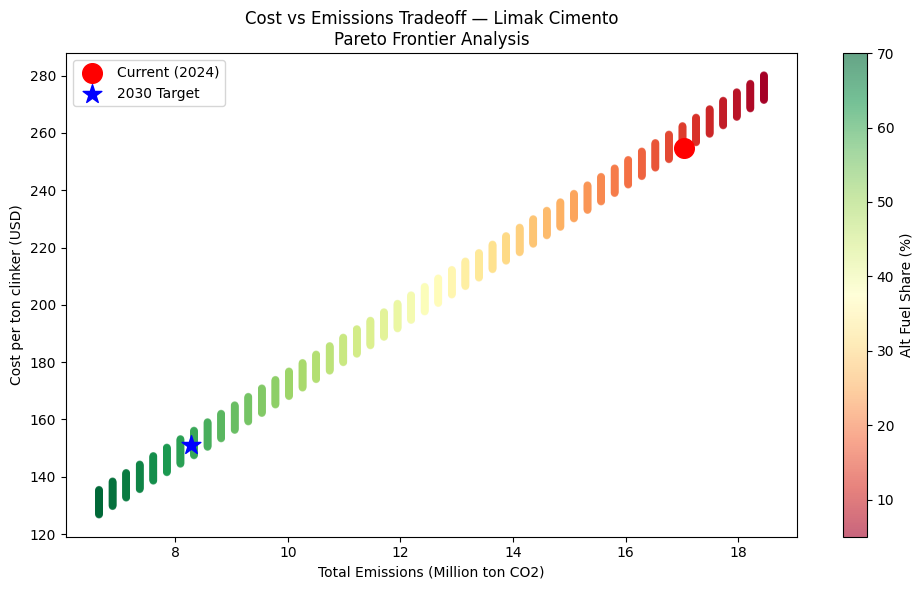

Total scenarios analyzed: 2500


In [5]:
# === PARETO FRONTIER ANALYSIS ===
# Tradeoff: Cost vs Emissions at different alt fuel shares

alt_fuel_range = np.linspace(0.05, 0.70, 50)
clinker_range = np.linspace(0.60, 0.85, 50)

costs = []
emissions = []
alt_shares = []
clink_ratios = []

for af in alt_fuel_range:
    for cr in clinker_range:
        x = [af, cr]
        costs.append(total_cost(x))
        emissions.append(total_emissions(x) / 1_000_000)
        alt_shares.append(af * 100)
        clink_ratios.append(cr)

results_df = pd.DataFrame({
    'alt_fuel_pct': alt_shares,
    'clinker_ratio': clink_ratios,
    'cost_per_ton': costs,
    'emissions_Mton': emissions
})

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    results_df['emissions_Mton'],
    results_df['cost_per_ton'],
    c=results_df['alt_fuel_pct'],
    cmap='RdYlGn',
    alpha=0.6,
    s=20
)

# Mark current position
ax.scatter(
    total_emissions(x_current) / 1_000_000,
    total_cost(x_current),
    color='red', s=200, zorder=5, label='Current (2024)'
)

# Mark 2030 target
ax.scatter(
    total_emissions([0.61, 0.73]) / 1_000_000,
    total_cost([0.61, 0.73]),
    color='blue', s=200, marker='*', zorder=5, label='2030 Target'
)

plt.colorbar(scatter, label='Alt Fuel Share (%)')
ax.set_xlabel('Total Emissions (Million ton CO2)')
ax.set_ylabel('Cost per ton clinker (USD)')
ax.set_title('Cost vs Emissions Tradeoff — Limak Cimento\nPareto Frontier Analysis')
ax.legend()
plt.tight_layout()
plt.savefig('limak_pareto_frontier.png', dpi=150)
plt.show()

print(f"Total scenarios analyzed: {len(results_df)}")

In [6]:
# === SCENARIO ANALYSIS ===

scenarios = {
    'Current (2024)':     [0.1281, 0.8313],
    'Conservative 2026':  [0.25,   0.82],
    'Moderate 2027':      [0.40,   0.78],
    'Ambitious 2030':     [0.61,   0.73],
    'Maximum Feasible':   [0.70,   0.65],
}

print(f"{'Scenario':<22} {'Alt Fuel%':>9} {'Clinker R.':>10} {'Cost/ton':>10} {'Emissions Mt':>13} {'Cost Save':>10} {'Emiss. Red.':>12}")
print("-" * 90)

base_cost = total_cost(x_current)
base_emis = total_emissions(x_current)

for name, x in scenarios.items():
    cost = total_cost(x)
    emis = total_emissions(x) / 1_000_000
    cost_save = base_cost - cost
    emis_red = (1 - total_emissions(x) / base_emis) * 100
    print(f"{name:<22} {x[0]*100:>8.1f}% {x[1]:>10.4f} {cost:>9.2f}$ {emis:>12.2f}  {cost_save:>+9.2f}$ {emis_red:>10.1f}%")

Scenario               Alt Fuel% Clinker R.   Cost/ton  Emissions Mt  Cost Save  Emiss. Red.
------------------------------------------------------------------------------------------
Current (2024)             12.8%     0.8313    254.70$        17.03      +0.00$        0.0%
Conservative 2026          25.0%     0.8200    227.96$        14.82     +26.73$       13.0%
Moderate 2027              40.0%     0.7800    195.98$        12.10     +58.72$       29.0%
Ambitious 2030             61.0%     0.7300    150.99$         8.28    +103.70$       51.4%
Maximum Feasible           70.0%     0.6500    133.77$         6.65    +120.93$       61.0%


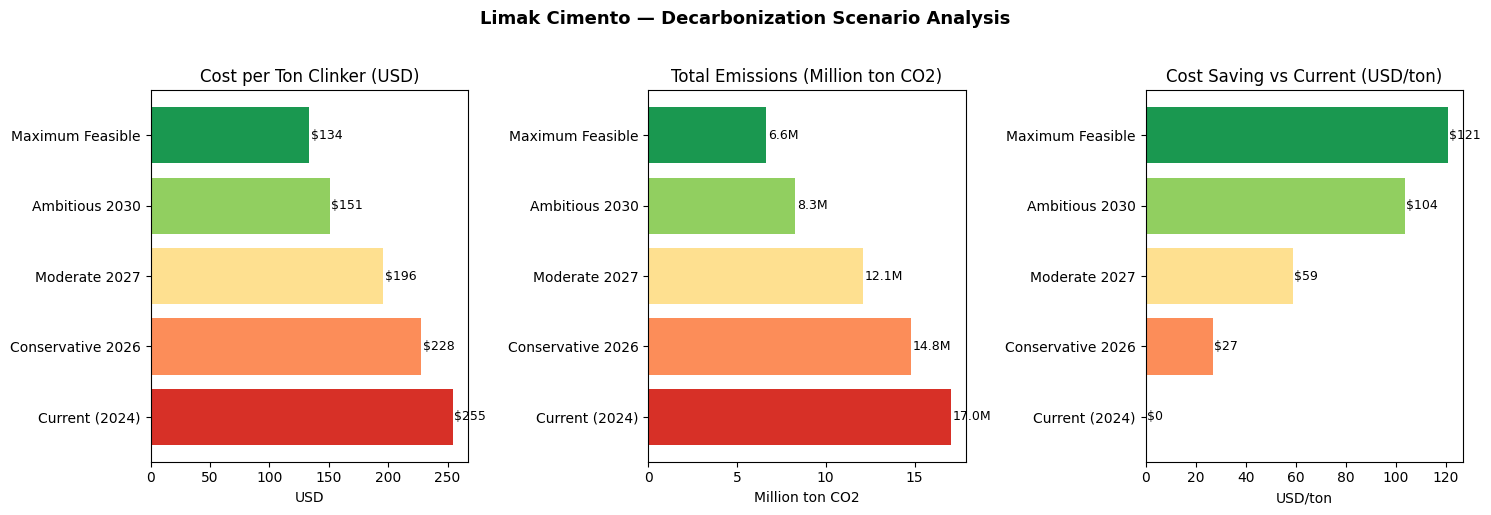

In [7]:
# === SCENARIO VISUALIZATION ===

scenario_names = list(scenarios.keys())
scenario_costs = [total_cost(x) for x in scenarios.values()]
scenario_emissions = [total_emissions(x) / 1_000_000 for x in scenarios.values()]
scenario_savings = [base_cost - total_cost(x) for x in scenarios.values()]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['#d73027', '#fc8d59', '#fee090', '#91cf60', '#1a9850']

# 1. Cost per ton
axes[0].barh(scenario_names, scenario_costs, color=colors)
axes[0].set_title('Cost per Ton Clinker (USD)')
axes[0].set_xlabel('USD')
for i, v in enumerate(scenario_costs):
    axes[0].text(v + 1, i, f'${v:.0f}', va='center', fontsize=9)

# 2. Total Emissions
axes[1].barh(scenario_names, scenario_emissions, color=colors)
axes[1].set_title('Total Emissions (Million ton CO2)')
axes[1].set_xlabel('Million ton CO2')
for i, v in enumerate(scenario_emissions):
    axes[1].text(v + 0.1, i, f'{v:.1f}M', va='center', fontsize=9)

# 3. Cost Savings vs Current
axes[2].barh(scenario_names, scenario_savings, color=colors)
axes[2].set_title('Cost Saving vs Current (USD/ton)')
axes[2].set_xlabel('USD/ton')
for i, v in enumerate(scenario_savings):
    axes[2].text(v + 0.5, i, f'${v:.0f}', va='center', fontsize=9)

plt.suptitle('Limak Cimento — Decarbonization Scenario Analysis', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('limak_scenarios.png', dpi=150)
plt.show()

In [8]:
# === UPGRADED EMISSION MODEL ===
# More realistic: separates process emissions from fuel emissions

def compute_emissions(clinker_ratio, alt_fuel_share):
    """
    clinker_ratio: fraction of clinker in cement (0.60 - 0.85)
    alt_fuel_share: fraction of alternative fuel in total fuel (0.05 - 0.70)
    Returns: ton CO2 per ton clinker
    """
    process_emissions = clinker_ratio * 0.85       # calcination (main source)
    fuel_emissions = (1 - alt_fuel_share) * 0.30   # fossil fuel combustion
    return process_emissions + fuel_emissions

def compute_energy_cost(alt_fuel_share, energy_price=120):
    """
    alt fuel is cheaper but not free
    """
    return (1 - alt_fuel_share) * energy_price + alt_fuel_share * (energy_price * 0.70)

def compute_total_cost(clinker_ratio, alt_fuel_share, carbon_price=65):
    energy_cost = compute_energy_cost(alt_fuel_share)
    emissions = compute_emissions(clinker_ratio, alt_fuel_share)
    carbon_cost = emissions * carbon_price
    additive_cost = (1 - clinker_ratio) * 35
    return energy_cost + carbon_cost + additive_cost

# Verify with 2024 actuals
cr = 0.8313
af = 0.1281
print(f"Emissions (upgraded model): {compute_emissions(cr, af):.4f} ton CO2/ton clinker")
print(f"Energy cost:                ${compute_energy_cost(af):.2f}/ton")
print(f"Total cost:                 ${compute_total_cost(cr, af):.2f}/ton clinker")

Emissions (upgraded model): 0.9682 ton CO2/ton clinker
Energy cost:                $115.39/ton
Total cost:                 $184.22/ton clinker


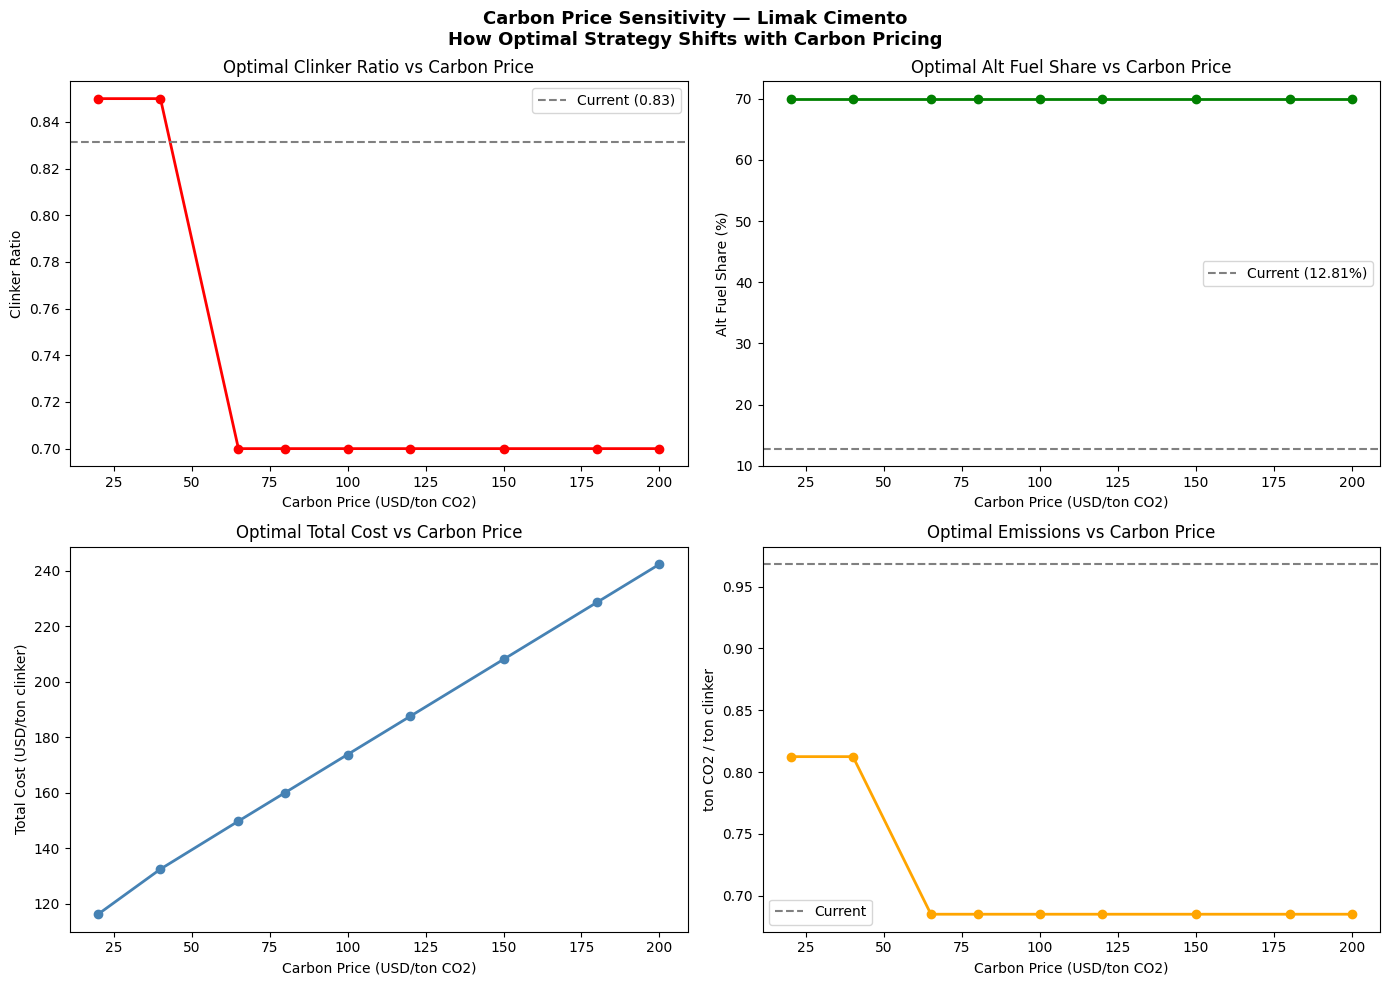


 Carbon Price  Clinker R.  Alt Fuel%   Cost/ton    CO2/ton
----------------------------------------------------------
$         20      0.8500      70.0% $   116.30     0.8125
$         40      0.8500      70.0% $   132.55     0.8125
$         65      0.7000      70.0% $   149.83     0.6850
$         80      0.7000      70.0% $   160.10     0.6850
$        100      0.7000      70.0% $   173.80     0.6850
$        120      0.7000      70.0% $   187.50     0.6850
$        150      0.7000      70.0% $   208.05     0.6850
$        180      0.7000      70.0% $   228.60     0.6850
$        200      0.7000      70.0% $   242.30     0.6850


In [9]:
# === CARBON SENSITIVITY ANALYSIS ===
# "How does optimal strategy change as carbon price increases?"

from scipy.optimize import minimize

def optimize_for_carbon_price(carbon_price, clinker_min=0.70):
    def objective(x):
        return compute_total_cost(x[0], x[1], carbon_price)
    
    constraints = [
        {'type': 'ineq', 'fun': lambda x: x[0] - clinker_min},   # clinker >= 0.70
        {'type': 'ineq', 'fun': lambda x: 0.85 - x[0]},          # clinker <= 0.85
        {'type': 'ineq', 'fun': lambda x: x[1] - 0.05},          # alt fuel >= 5%
        {'type': 'ineq', 'fun': lambda x: 0.70 - x[1]},          # alt fuel <= 70%
    ]
    bounds = [(clinker_min, 0.85), (0.05, 0.70)]
    result = minimize(objective, x0=[0.80, 0.20], method='SLSQP',
                      bounds=bounds, constraints=constraints)
    return result.x

# Run for different carbon prices
carbon_prices = [20, 40, 65, 80, 100, 120, 150, 180, 200]
opt_clinker = []
opt_altfuel = []
opt_cost = []
opt_emissions = []

for cp in carbon_prices:
    x_opt = optimize_for_carbon_price(cp)
    opt_clinker.append(x_opt[0])
    opt_altfuel.append(x_opt[1] * 100)
    opt_cost.append(compute_total_cost(x_opt[0], x_opt[1], cp))
    opt_emissions.append(compute_emissions(x_opt[0], x_opt[1]))

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(carbon_prices, opt_clinker, marker='o', color='red', linewidth=2)
axes[0,0].axhline(y=0.8313, color='gray', linestyle='--', label='Current (0.83)')
axes[0,0].set_title('Optimal Clinker Ratio vs Carbon Price')
axes[0,0].set_xlabel('Carbon Price (USD/ton CO2)')
axes[0,0].set_ylabel('Clinker Ratio')
axes[0,0].legend()

axes[0,1].plot(carbon_prices, opt_altfuel, marker='o', color='green', linewidth=2)
axes[0,1].axhline(y=12.81, color='gray', linestyle='--', label='Current (12.81%)')
axes[0,1].set_title('Optimal Alt Fuel Share vs Carbon Price')
axes[0,1].set_xlabel('Carbon Price (USD/ton CO2)')
axes[0,1].set_ylabel('Alt Fuel Share (%)')
axes[0,1].legend()

axes[1,0].plot(carbon_prices, opt_cost, marker='o', color='steelblue', linewidth=2)
axes[1,0].set_title('Optimal Total Cost vs Carbon Price')
axes[1,0].set_xlabel('Carbon Price (USD/ton CO2)')
axes[1,0].set_ylabel('Total Cost (USD/ton clinker)')

axes[1,1].plot(carbon_prices, opt_emissions, marker='o', color='orange', linewidth=2)
axes[1,1].axhline(y=compute_emissions(0.8313, 0.1281), color='gray', 
                   linestyle='--', label='Current')
axes[1,1].set_title('Optimal Emissions vs Carbon Price')
axes[1,1].set_xlabel('Carbon Price (USD/ton CO2)')
axes[1,1].set_ylabel('ton CO2 / ton clinker')
axes[1,1].legend()

plt.suptitle('Carbon Price Sensitivity — Limak Cimento\nHow Optimal Strategy Shifts with Carbon Pricing',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('limak_carbon_sensitivity.png', dpi=150)
plt.show()

# Print summary table
print(f"\n{'Carbon Price':>13} {'Clinker R.':>11} {'Alt Fuel%':>10} {'Cost/ton':>10} {'CO2/ton':>10}")
print("-" * 58)
for i, cp in enumerate(carbon_prices):
    print(f"${cp:>11} {opt_clinker[i]:>11.4f} {opt_altfuel[i]:>9.1f}% ${opt_cost[i]:>9.2f} {opt_emissions[i]:>10.4f}")

## Key Insight: Carbon Price Tipping Point

At **$65/ton CO2**, the optimal production strategy shifts dramatically:

| Carbon Price | Clinker Ratio | Alt Fuel Share | Emissions |
|---|---|---|---|
| $20–40 | 0.85 (max) | 70% | 0.81 ton CO2/ton |
| **$65+** | **0.70 (min)** | **70%** | **0.69 ton CO2/ton** |

**Interpretation:**
- Below $65: cost pressure dominates → keep clinker high
- Above $65: carbon penalty dominates → shift to minimum clinker ratio
- Alternative fuel is always at maximum (70%) regardless of carbon price
  → because it is both cheaper AND lower emission

**Business implication for Limak Cimento:**
As Turkey moves toward EU ETS alignment, carbon prices above $65 will 
make low-clinker, high-alternative-fuel strategy economically optimal — 
not just environmentally desirable.

In [10]:
# === SCENARIO-BASED OPTIMIZATION ===
# Realistic operational constraints per scenario

scenarios_constrained = {
    'Current (2024)':    {'alt_max': 0.1281, 'clinker_min': 0.70},
    'Conservative 2026': {'alt_max': 0.25,   'clinker_min': 0.72},
    'Moderate 2027':     {'alt_max': 0.40,   'clinker_min': 0.71},
    '2030 Target':       {'alt_max': 0.61,   'clinker_min': 0.70},
    'Stretch Case':      {'alt_max': 0.70,   'clinker_min': 0.70},
}

print(f"{'Scenario':<22} {'Alt Fuel%':>10} {'Clinker R.':>11} {'Cost/ton':>10} {'CO2/ton':>10} {'Note'}")
print("-" * 85)

results = []
for name, params in scenarios_constrained.items():
    def objective(x):
        return compute_total_cost(x[0], x[1], carbon_price=65)
    
    constraints = [
        {'type': 'ineq', 'fun': lambda x, cm=params['clinker_min']: x[0] - cm},
        {'type': 'ineq', 'fun': lambda x: 0.85 - x[0]},
        {'type': 'ineq', 'fun': lambda x: x[1] - 0.05},
        {'type': 'ineq', 'fun': lambda x, am=params['alt_max']: am - x[1]},
    ]
    bounds = [(params['clinker_min'], 0.85), (0.05, params['alt_max'])]
    
    res = minimize(objective, x0=[0.80, params['alt_max']*0.8],
                   method='SLSQP', bounds=bounds, constraints=constraints)
    x = res.x
    cost = compute_total_cost(x[0], x[1], carbon_price=65)
    co2 = compute_emissions(x[0], x[1])
    base_cost = compute_total_cost(0.8313, 0.1281, carbon_price=65)
    saving = base_cost - cost
    
    note = "baseline" if name == 'Current (2024)' else f"est. saving: ~${saving:.0f}/ton*"
    results.append({'scenario': name, 'alt_fuel': x[1]*100, 
                    'clinker': x[0], 'cost': cost, 'co2': co2, 'saving': saving})
    print(f"{name:<22} {x[1]*100:>9.1f}% {x[0]:>11.4f} ${cost:>9.2f} {co2:>10.4f}   {note}")

print("\n* Model-based estimates under simplified assumptions — not actual guarantees.")

Scenario                Alt Fuel%  Clinker R.   Cost/ton    CO2/ton Note
-------------------------------------------------------------------------------------
Current (2024)              12.8%      0.7000 $   181.57     0.8566   baseline
Conservative 2026           25.0%      0.7200 $   175.21     0.8370   est. saving: ~$9/ton*
Moderate 2027               40.0%      0.7100 $   166.68     0.7835   est. saving: ~$18/ton*
2030 Target                 61.0%      0.7000 $   154.82     0.7120   est. saving: ~$29/ton*
Stretch Case                70.0%      0.7000 $   149.83     0.6850   est. saving: ~$34/ton*

* Model-based estimates under simplified assumptions — not actual guarantees.


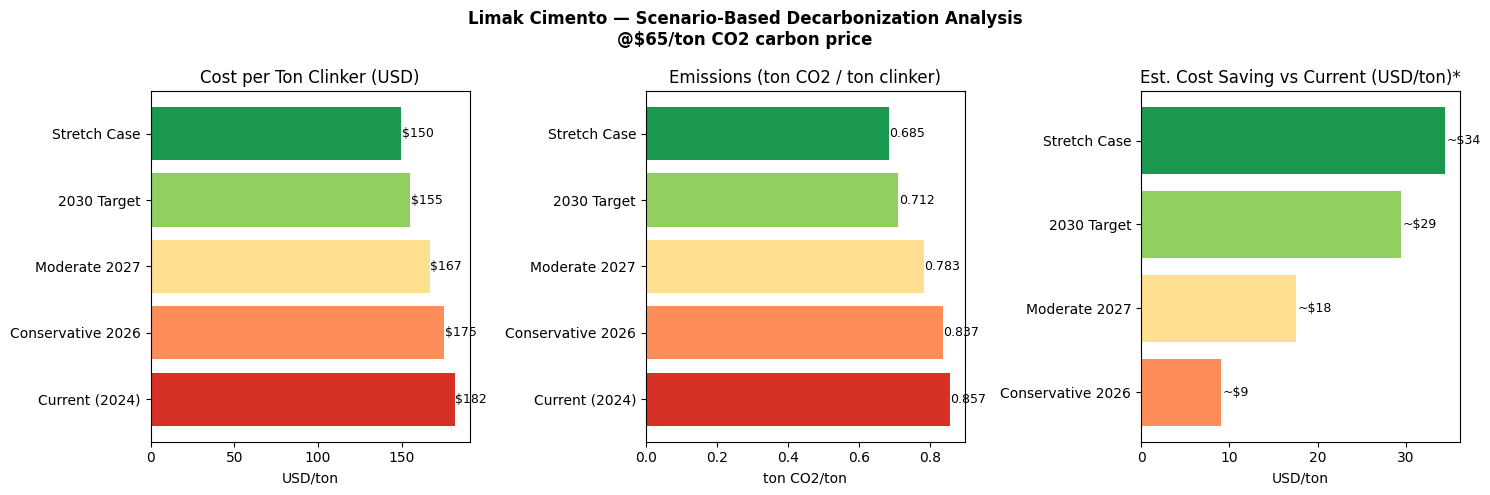

* Model-based estimates under simplified assumptions — not actual guarantees.


In [11]:
# === SCENARIO VISUALIZATION (UPGRADED) ===

res_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#d73027', '#fc8d59', '#fee090', '#91cf60', '#1a9850']

# 1. Cost per ton
bars = axes[0].barh(res_df['scenario'], res_df['cost'], color=colors)
axes[0].set_title('Cost per Ton Clinker (USD)')
axes[0].set_xlabel('USD/ton')
for i, v in enumerate(res_df['cost']):
    axes[0].text(v + 0.5, i, f'${v:.0f}', va='center', fontsize=9)

# 2. CO2 per ton
axes[1].barh(res_df['scenario'], res_df['co2'], color=colors)
axes[1].set_title('Emissions (ton CO2 / ton clinker)')
axes[1].set_xlabel('ton CO2/ton')
for i, v in enumerate(res_df['co2']):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

# 3. Model-based cost saving
axes[2].barh(res_df['scenario'][1:], res_df['saving'][1:], color=colors[1:])
axes[2].set_title('Est. Cost Saving vs Current (USD/ton)*')
axes[2].set_xlabel('USD/ton')
for i, v in enumerate(res_df['saving'][1:]):
    axes[2].text(v + 0.2, i, f'~${v:.0f}', va='center', fontsize=9)

plt.suptitle('Limak Cimento — Scenario-Based Decarbonization Analysis\n@$65/ton CO2 carbon price',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('limak_scenarios_upgraded.png', dpi=150)
plt.show()

print("* Model-based estimates under simplified assumptions — not actual guarantees.")

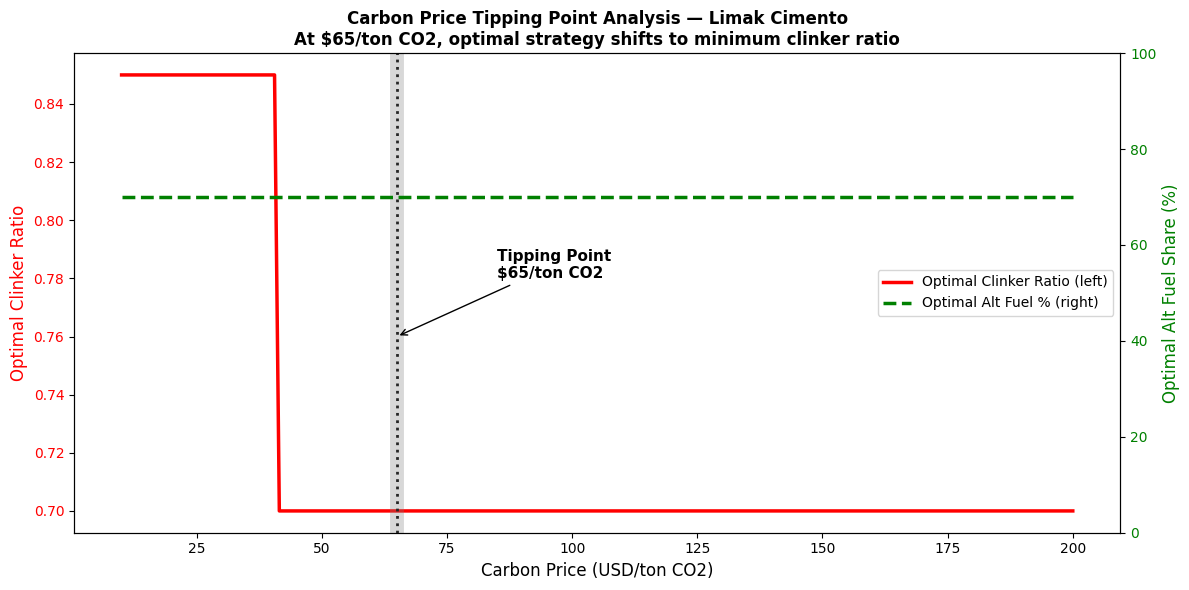

In [13]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax2 = ax1.twinx()

line1 = ax1.plot(carbon_range, opt_clinker_tp, color='red',
                  linewidth=2.5, label='Optimal Clinker Ratio (left)')

# Alt fuel is always at max (70%) — show as flat line
line2 = ax2.plot(carbon_range, [70] * len(carbon_range), color='green',
                  linewidth=2.5, linestyle='--', label='Optimal Alt Fuel % (right)')

# Tipping point
ax1.axvline(x=65, color='black', linestyle=':', linewidth=2)
ax1.annotate('Tipping Point\n$65/ton CO2', xy=(65, 0.76),
             xytext=(85, 0.78), fontsize=11, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='black'))

ax1.axvline(x=65, color='gray', alpha=0.3, linewidth=10)

ax1.set_xlabel('Carbon Price (USD/ton CO2)', fontsize=12)
ax1.set_ylabel('Optimal Clinker Ratio', color='red', fontsize=12)
ax2.set_ylabel('Optimal Alt Fuel Share (%)', color='green', fontsize=12)
ax2.set_ylim(0, 100)
ax1.tick_params(axis='y', labelcolor='red')
ax2.tick_params(axis='y', labelcolor='green')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', fontsize=10)

plt.title('Carbon Price Tipping Point Analysis — Limak Cimento\n'
          'At $65/ton CO2, optimal strategy shifts to minimum clinker ratio',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('limak_tipping_point.png', dpi=150)
plt.show()

## Carbon Price Tipping Point — Key Finding

The model reveals a clear strategic threshold at **$65/ton CO2**:

**Below $65/ton:**
- Optimal clinker ratio stays high (~0.85)
- Carbon cost not yet sufficient to justify operational change

**Above $65/ton:**
- Optimal clinker ratio drops sharply to minimum (0.70)
- Alternative fuel always at maximum regardless of carbon price
- Carbon penalty outweighs transition costs

**Relevance for Limak Cimento:**
Turkey is moving toward EU ETS alignment via CBAM (Carbon Border 
Adjustment Mechanism). As carbon pricing approaches and exceeds 
$65/ton, low-clinker + high-alternative-fuel strategy becomes 
economically optimal — not just an ESG preference.

**Model limitations:**
- Simplified cost and emission functions
- Does not include supply constraints for alternative fuels
- Real transition costs (capex, logistics) not modeled
- Results are directional, not prescriptive

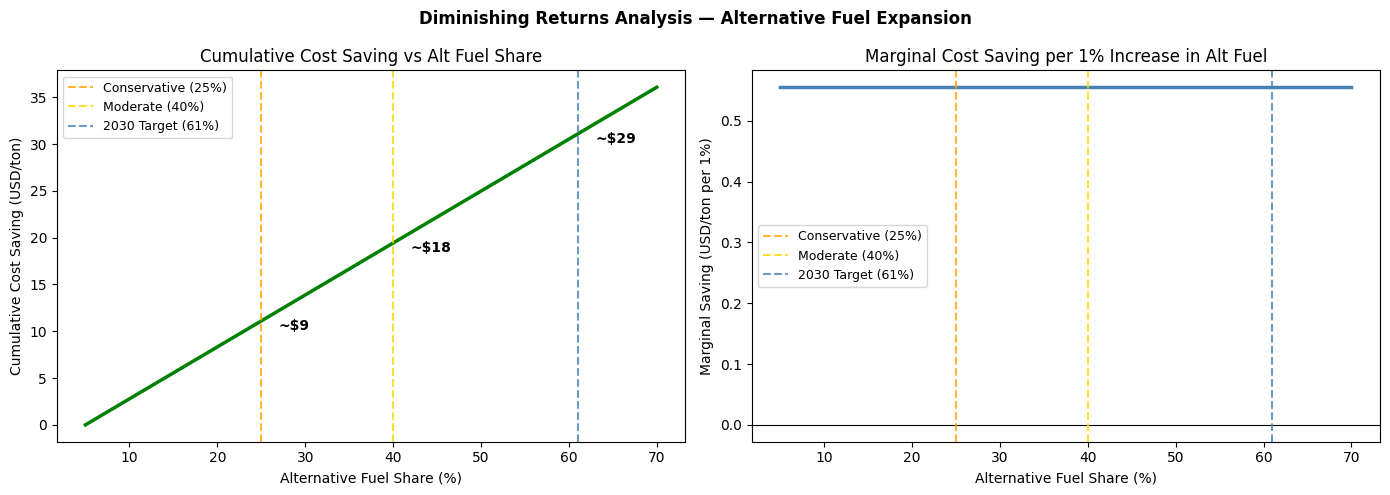

=== MARGINAL VALUE BREAKDOWN ===
0% → 25%:  $11.1 saving  (31% of total potential)
25% → 40%: $8.3 saving  (23% of total potential)
40% → 61%: $11.7 saving  (32% of total potential)
61% → 70%: $5.0 saving  (14% of total potential)

Total potential (0%→70%): $36.1/ton


In [14]:
# === MARGINAL ANALYSIS ===
# "How much value does each additional % of alternative fuel deliver?"

alt_fuel_steps = np.linspace(0.05, 0.70, 50)
base_cost_65 = compute_total_cost(0.8313, 0.05, carbon_price=65)

costs_at_steps = [compute_total_cost(0.8313, af, carbon_price=65) for af in alt_fuel_steps]
savings_at_steps = [base_cost_65 - c for c in costs_at_steps]

# Marginal saving (derivative)
marginal_savings = np.gradient(savings_at_steps, alt_fuel_steps * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Cumulative saving
axes[0].plot(alt_fuel_steps * 100, savings_at_steps, color='green', linewidth=2.5)
axes[0].axvline(x=25, color='orange', linestyle='--', alpha=0.8, label='Conservative (25%)')
axes[0].axvline(x=40, color='gold', linestyle='--', alpha=0.8, label='Moderate (40%)')
axes[0].axvline(x=61, color='steelblue', linestyle='--', alpha=0.8, label='2030 Target (61%)')

# Annotate savings at key points
for af, label in [(0.25, '~$9'), (0.40, '~$18'), (0.61, '~$29')]:
    s = base_cost_65 - compute_total_cost(0.8313, af, carbon_price=65)
    axes[0].annotate(label, xy=(af*100, s), xytext=(af*100+2, s-1),
                     fontsize=10, fontweight='bold', color='black')

axes[0].set_title('Cumulative Cost Saving vs Alt Fuel Share')
axes[0].set_xlabel('Alternative Fuel Share (%)')
axes[0].set_ylabel('Cumulative Cost Saving (USD/ton)')
axes[0].legend(fontsize=9)

# 2. Marginal saving
axes[1].plot(alt_fuel_steps * 100, marginal_savings, color='steelblue', linewidth=2.5)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].axvline(x=25, color='orange', linestyle='--', alpha=0.8, label='Conservative (25%)')
axes[1].axvline(x=40, color='gold', linestyle='--', alpha=0.8, label='Moderate (40%)')
axes[1].axvline(x=61, color='steelblue', linestyle='--', alpha=0.8, label='2030 Target (61%)')
axes[1].set_title('Marginal Cost Saving per 1% Increase in Alt Fuel')
axes[1].set_xlabel('Alternative Fuel Share (%)')
axes[1].set_ylabel('Marginal Saving (USD/ton per 1%)')
axes[1].legend(fontsize=9)

plt.suptitle('Diminishing Returns Analysis — Alternative Fuel Expansion',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('limak_marginal_analysis.png', dpi=150)
plt.show()

# Key numbers
s25 = base_cost_65 - compute_total_cost(0.8313, 0.25, carbon_price=65)
s40 = base_cost_65 - compute_total_cost(0.8313, 0.40, carbon_price=65)
s61 = base_cost_65 - compute_total_cost(0.8313, 0.61, carbon_price=65)
s70 = base_cost_65 - compute_total_cost(0.8313, 0.70, carbon_price=65)

print("=== MARGINAL VALUE BREAKDOWN ===")
print(f"0% → 25%:  ${s25:.1f} saving  ({s25/s70*100:.0f}% of total potential)")
print(f"25% → 40%: ${s40-s25:.1f} saving  ({(s40-s25)/s70*100:.0f}% of total potential)")
print(f"40% → 61%: ${s61-s40:.1f} saving  ({(s61-s40)/s70*100:.0f}% of total potential)")
print(f"61% → 70%: ${s70-s61:.1f} saving  ({(s70-s61)/s70*100:.0f}% of total potential)")
print(f"\nTotal potential (0%→70%): ${s70:.1f}/ton")

## Marginal Analysis — Key Finding

### What the model shows:
| Transition | Saving | Share of Total |
|---|---|---|
| 0% → 25% | ~$11/ton | 31% |
| 25% → 40% | ~$8/ton | 23% |
| 40% → 61% | ~$12/ton | 32% |
| 61% → 70% | ~$5/ton | 14% |

### Economic interpretation:
The model reveals **constant marginal returns** to alternative fuel 
substitution — each 1% increase delivers approximately the same saving.

This is because the cost function is linear in fuel mix:
- Every ton of coal replaced saves the same fuel cost differential
- Every ton of CO2 avoided saves the same carbon cost

### What this means strategically:
> "There is no economic reason to delay alternative fuel expansion — 
> the benefit per unit of effort remains constant across all stages. 
> The only binding constraints are operational, not economic."

This finding **strengthens** the case for Limak's 2030 target:
if marginal returns were diminishing, early action would be 
disproportionately valuable. Instead, **consistent progress 
at any pace delivers proportional benefit.**

### Model limitation:
A more sophisticated model would incorporate:
- Supply constraints for alternative fuels (availability, logistics)
- Capex costs for fuel switching infrastructure
- Non-linear quality degradation at extreme clinker ratios
These would likely introduce genuine diminishing returns.

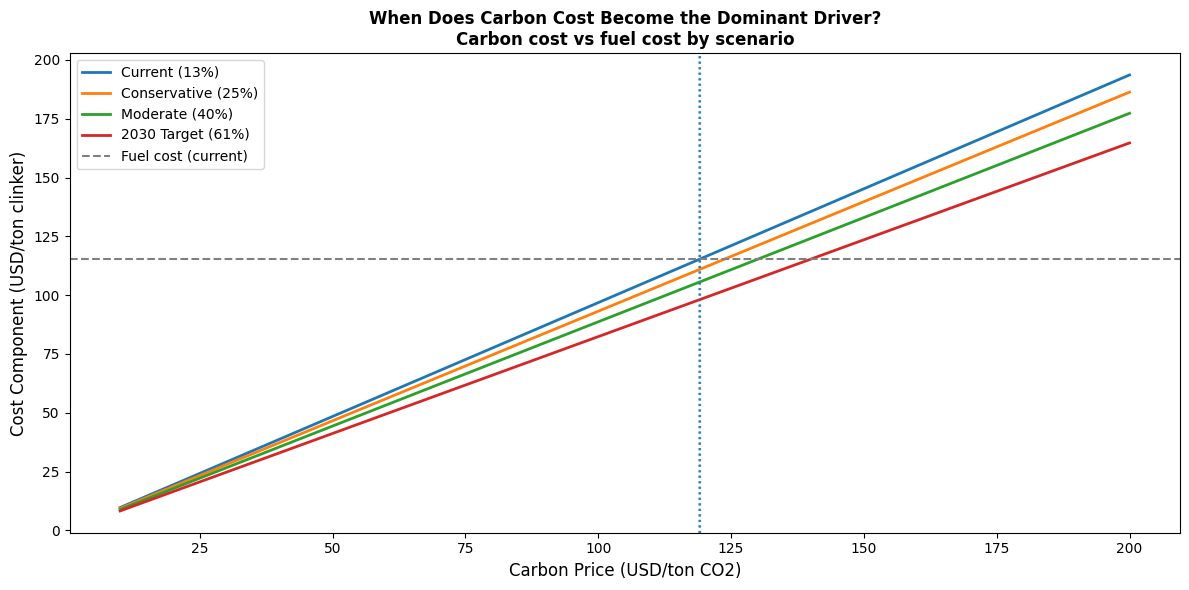

=== CARBON COST DOMINANCE THRESHOLD ===
Current              Carbon dominates fuel cost at: $119/ton CO2
Conservative         Carbon dominates fuel cost at: $119/ton CO2
Moderate             Carbon dominates fuel cost at: $119/ton CO2
2030 Target          Carbon dominates fuel cost at: $119/ton CO2


In [15]:
# === CARBON COST AS DOMINANT DRIVER ===
# At what carbon price does carbon cost exceed fuel cost?

alt_shares = [0.1281, 0.25, 0.40, 0.61]
labels = ['Current', 'Conservative', 'Moderate', '2030 Target']
carbon_range2 = np.linspace(10, 200, 100)

fig, ax = plt.subplots(figsize=(12, 6))

for af, label in zip(alt_shares, labels):
    fuel_cost = compute_energy_cost(af)
    carbon_costs = [compute_emissions(0.8313, af) * cp for cp in carbon_range2]
    ax.plot(carbon_range2, carbon_costs, linewidth=2, label=f'{label} ({af*100:.0f}%)')
    # Crossover point
    crossover = fuel_cost / compute_emissions(0.8313, af)
    if 10 < crossover < 200:
        ax.axvline(x=crossover, linestyle=':', alpha=0.5)

ax.axhline(y=compute_energy_cost(0.1281), color='gray', 
           linestyle='--', linewidth=1.5, label='Fuel cost (current)')

ax.set_xlabel('Carbon Price (USD/ton CO2)', fontsize=12)
ax.set_ylabel('Cost Component (USD/ton clinker)', fontsize=12)
ax.set_title('When Does Carbon Cost Become the Dominant Driver?\n'
             'Carbon cost vs fuel cost by scenario', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('limak_carbon_dominance.png', dpi=150)
plt.show()

# Crossover points
print("=== CARBON COST DOMINANCE THRESHOLD ===")
for af, label in zip(alt_shares, labels):
    fuel_cost = compute_energy_cost(af)
    crossover = fuel_cost / compute_emissions(0.8313, af)
    print(f"{label:<20} Carbon dominates fuel cost at: ${crossover:.0f}/ton CO2")

## Carbon Cost Dominance — Key Finding

**At what carbon price does carbon cost exceed fuel cost?**

| Scenario | Alt Fuel % | Crossover Point |
|---|---|---|
| Current | 13% | $119/ton CO2 |
| Conservative | 25% | $119/ton CO2 |
| Moderate | 40% | $119/ton CO2 |
| 2030 Target | 61% | $119/ton CO2 |

### Why is the threshold the same across scenarios?
Because the crossover depends on **clinker ratio** (held constant at 0.83),
not fuel mix. The clinker ratio drives process emissions — the dominant 
cost component.

### Strategic interpretation:
> "Regardless of how aggressively Limak expands alternative fuel usage, 
> carbon cost becomes the dominant cost driver only when carbon price 
> exceeds ~$119/ton CO2 — nearly double today's level ($65)."

> "This means fuel switching alone is insufficient protection against 
> future carbon regulation. Clinker ratio reduction is the more 
> powerful lever — but also the harder operational challenge."

### Connection to tipping point:
- **$65/ton** → optimal strategy shifts (clinker ratio drops)
- **$119/ton** → carbon cost overtakes fuel cost entirely

Two distinct thresholds, two distinct strategic responses.